# Simulation of the scintillation quenching

In [1]:
pip install TDCRPy==2.20.12

Note: you may need to restart the kernel to use updated packages.


In [2]:
import tdcrpy as td
import matplotlib.pyplot as plt
import numpy as np

## Calculate the quenched energy from the Birks model

$dL/dx = (S * dE/dx) / (1 + kB * dE/dx + C * (dE/dx)^2)$

It include the [second order correction for biomolecular effect](https://journals.aps.org/pr/abstract/10.1103/PhysRev.87.376) parametrized with the chou parameter $C$. It is set by defaut to 0.

In [3]:
kB = 0.01  # Birks constant in cm/MeV
C = 0      # Chou constant in cm2/MeV2
ei = 1000  # initial energy in keV
ed = 1000  # deposited energy in keV
nE = 10000 # number of points of the energy linear space


eq_e=td.TDCR_model_lib.E_quench_e(ei*1e3,ed*1e3,kB,nE,kC=C)*1e-3
print(f"For electrons       => Initial energy = {ei} keV, deposited energy = {ed} keV, quenched energy = {eq_e:.5g} keV")
eq_a=td.TDCR_model_lib.E_quench_a(ei,kB*1e-3,nE)
print(f"For alpha particles => Initial energy = {ei} keV, quenched energy = {eq_a:.5g} keV")

For electrons       => Initial energy = 1000 keV, deposited energy = 1000 keV, quenched energy = 971.61 keV
For alpha particles => Initial energy = 1000 keV, quenched energy = 47.99 keV


## Correction of the reverse micelle effect

To be described...

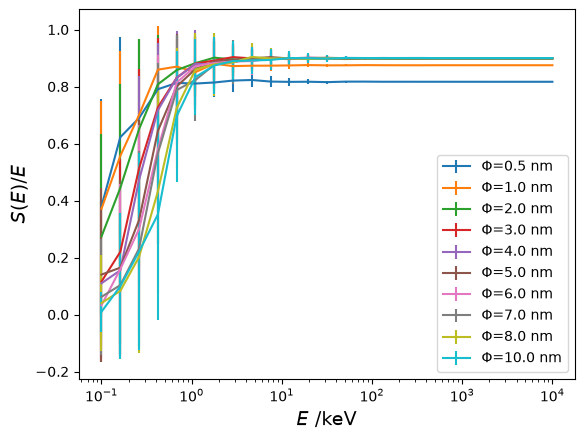

In [4]:
energy_vec = np.logspace(-1,4,25) # in keV
n=len(energy_vec)
fAq=0.1 # aqueous phase fraction in the source
nTrial = 100
s05, s1, s2, s3, s4, s5, s6, s7, s8, s10 = np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n)
us05, us1, us2, us3, us4, us5, us6, us7, us8, us10 = np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n), np.empty(n)
for i, e in enumerate(energy_vec):
    s05[i], us05[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=0.5,num_samples=nTrial)
    s1[i], us1[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=1.0,num_samples=nTrial)
    s2[i], us2[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=2.0,num_samples=nTrial)
    s3[i], us3[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=3.0,num_samples=nTrial)
    s4[i], us4[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=4.0,num_samples=nTrial)
    s5[i], us5[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=5.0,num_samples=nTrial)
    s6[i], us6[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=6.0,num_samples=nTrial)
    s7[i], us7[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=7.0,num_samples=nTrial)
    s8[i], us8[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=8.0,num_samples=nTrial)
    s10[i], us10[i], _ = td.TDCR_model_lib.pure_mc_efficient_energy_numba(e,f_w=fAq,r_d_nm=10.0,num_samples=nTrial)

plt.figure("Deposited energy ratio")
plt.clf()
plt.errorbar(energy_vec,s05/energy_vec,yerr=us05/energy_vec,label=r"$\Phi$=0.5 nm")
plt.errorbar(energy_vec,s1/energy_vec,yerr=us1/energy_vec,label=r"$\Phi$=1.0 nm")
plt.errorbar(energy_vec,s2/energy_vec,yerr=us2/energy_vec,label=r"$\Phi$=2.0 nm")
plt.errorbar(energy_vec,s3/energy_vec,yerr=us3/energy_vec,label=r"$\Phi$=3.0 nm")
plt.errorbar(energy_vec,s4/energy_vec,yerr=us4/energy_vec,label=r"$\Phi$=4.0 nm")
plt.errorbar(energy_vec,s5/energy_vec,yerr=us5/energy_vec,label=r"$\Phi$=5.0 nm")
plt.errorbar(energy_vec,s6/energy_vec,yerr=us6/energy_vec,label=r"$\Phi$=6.0 nm")
plt.errorbar(energy_vec,s7/energy_vec,yerr=us7/energy_vec,label=r"$\Phi$=7.0 nm")
plt.errorbar(energy_vec,s8/energy_vec,yerr=us8/energy_vec,label=r"$\Phi$=8.0 nm")
plt.errorbar(energy_vec,s10/energy_vec,yerr=us10/energy_vec,label=r"$\Phi$=10.0 nm")
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$S(E)/E$', fontsize=14)
plt.legend()

## Scintillation quenching function from the Birks model

with and without the reverse micelle correction

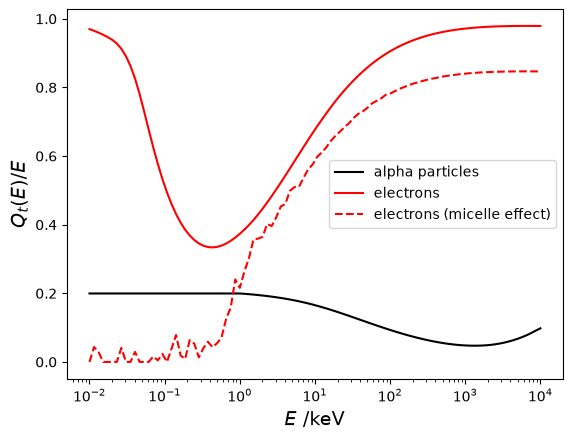

In [5]:
energy_vec = np.logspace(-2,4,100) # in keV
fAq = 0.13524 # acqueous fraction
diam_micelle = 4.0 # diameter of micelles (in nm) 

eq_a, eq_e, eq_e_m = [], [], []
for e in energy_vec:
        e_quenched = td.TDCR_model_lib.E_quench_e(e*1e3,e*1e3,kB,nE)*1e-3
        eq_e.append(e_quenched)
        eq_e_m.append(td.TDCR_model_lib.pure_mc_efficient_energy_numba(e_quenched,f_w=fAq,r_d_nm=diam_micelle,num_samples=20)[0])
        eq_a.append(td.TDCR_model_lib.E_quench_a(e,kB*1e-3,nE))

plt.figure("Quenched Energy")
plt.clf()
plt.plot(energy_vec,eq_a/energy_vec,"-k",label="alpha particles")
plt.plot(energy_vec,eq_e/energy_vec,"-r",label="electrons")
plt.plot(energy_vec,eq_e_m/energy_vec,"--r",label="electrons (micelle effect)")
plt.xscale('log')
plt.xlabel(r'$E$ /keV', fontsize=14)
plt.ylabel(r'$Q_t(E)/E$', fontsize=14)
plt.legend()